<a href="https://colab.research.google.com/github/tdineth/Image-Processing-CO5430-4th-sem/blob/main/E_23_076_Lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
file_path = "/content/drive/MyDrive/Image Processing - CO5430 - 4th sem/lab2"

### Task 1 — Visualize Intensity & Histograms



```
hist3=cv2.calcHist([img3],[0],None,[256],[0,256])
```



[img3] — the source image (wrapped in a list because OpenCV supports multi‑image histograms).

[0] — the channel index.

  - 0 = grayscale or the Blue channel if the image is BGR.

None — no mask (use the whole image).

[256] — number of bins (one for each intensity level).

[0,256] — the intensity range to consider.

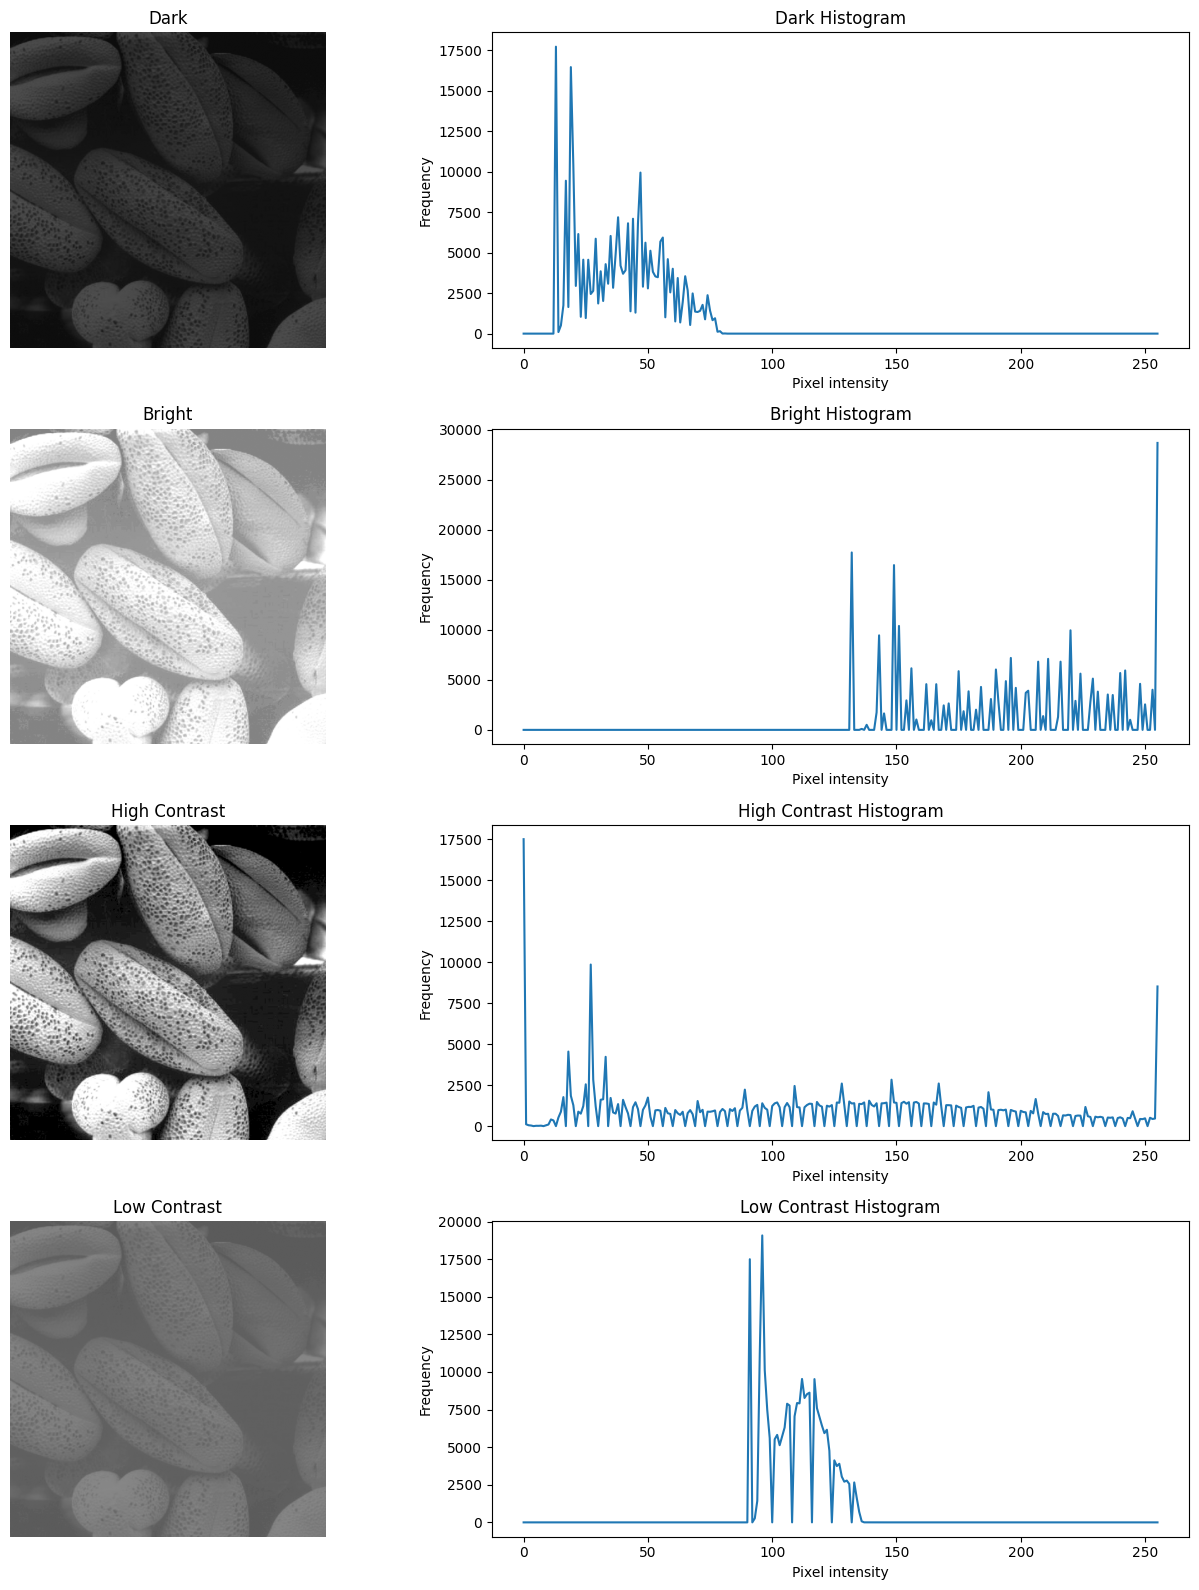

In [26]:
img1=cv2.imread(f"{file_path}/dark.tif",0)
img2=cv2.imread(f"{file_path}/bright.tif",0)
img3=cv2.imread(f"{file_path}/high_contrast.tif",0)
img4=cv2.imread(f"{file_path}/low_contrast.tif",0)

hist1=cv2.calcHist([img1],[0],None,[256],[0,256])
hist2=cv2.calcHist([img2],[0],None,[256],[0,256])
hist3=cv2.calcHist([img3],[0],None,[256],[0,256])
hist4=cv2.calcHist([img4],[0],None,[256],[0,256])

plt.figure(figsize=(14,16))

images=[img1,img2,img3,img4]
hists=[hist1,hist2,hist3,hist4]

titles=["Dark","Bright","High Contrast","Low Contrast"]

for i in range(4):

    plt.subplot(4,2,2*i+1)

    plt.imshow(
        images[i],
        cmap='gray',
        vmin=0,
        vmax=255
    )

    plt.title(titles[i])
    plt.axis("off")

    plt.subplot(4,2,2*i+2)

    plt.plot(hists[i])

    plt.title(
        titles[i]+" Histogram"
    )

    plt.xlabel("Pixel intensity")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Describe how the histogram shape relates to the lighting condition and why understanding distribution is
essential for image processing**

The histogram shape directly reflects the lighting condition of an image because it shows how pixel intensities are distributed. The dark image histogram is concentrated toward lower intensity values around the left side, indicating that most pixels are dim. The bright image histogram shifts toward the right side with high intensity values, showing overexposed or highly illuminated regions. The high contrast image has a wide histogram spread across a larger intensity range which indicates strong separation between dark and bright areas. The low contrast image contains a narrow histogram concentrated within a small intensity range, causing the image to appear dull and lacking detail. Understanding intensity distribution is essential in image processing because histogram analysis helps identify illumination conditions and choose suitable enhancement methods such as contrast stretching, thresholding or histogram equalization. Without understanding pixel distribution, image enhancement and segmentation methods may produce poor results.

**If two images have similar histograms, can they still look visually different? Why?**

Yes. Histograms only show the distribution of intensity values and ignore spatial arrangement. Two images may contain identical pixel intensity distributions but place those pixels in completely different positions. Therefore visual appearance, shapes and object structures can differ significantly despite similar histograms.

### Task 2 — Manual Threshold & Observe Failure Cases

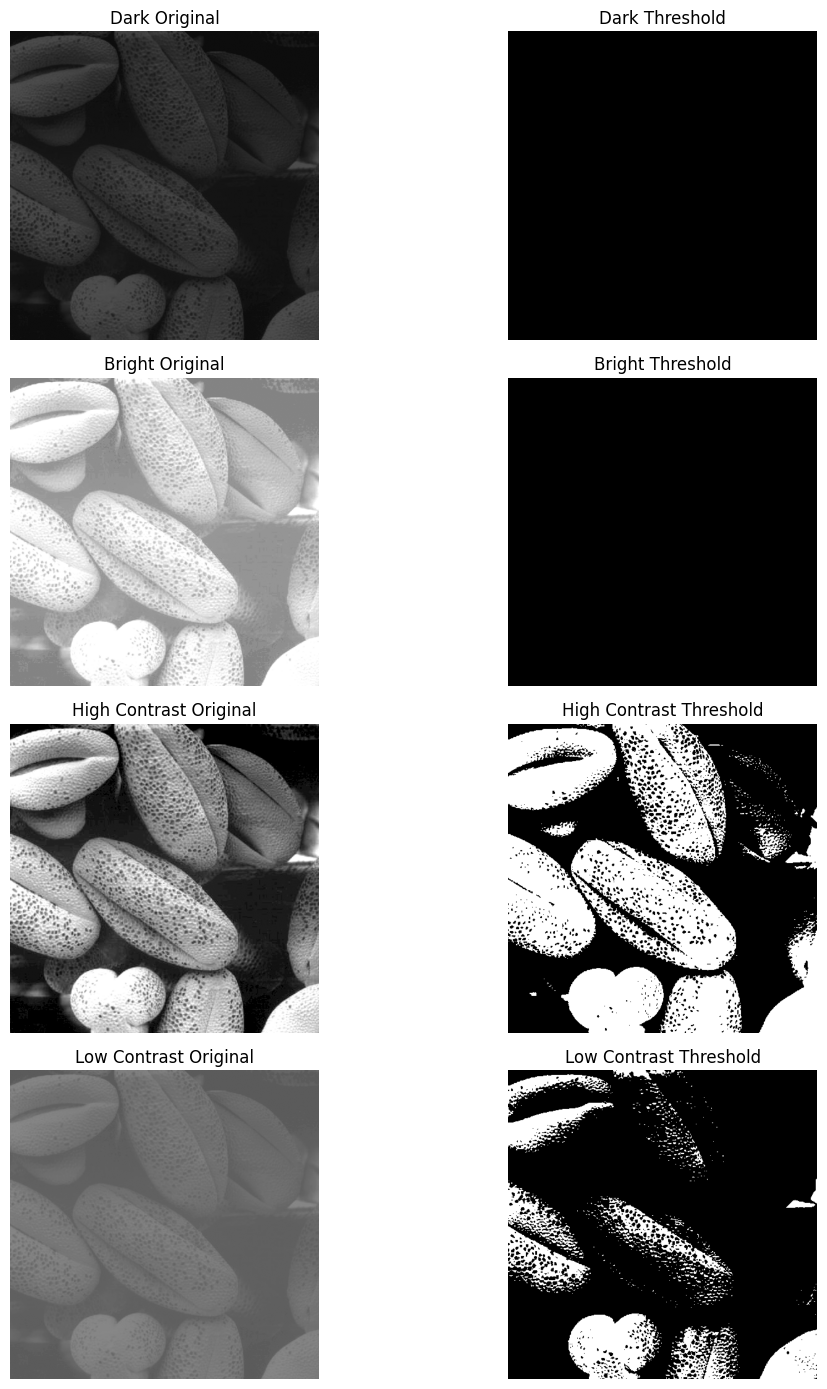

In [27]:
threshold=120

images=[img1,img2,img3,img4]
titles=["Dark","Bright","High Contrast","Low Contrast"]

plt.figure(figsize=(12,14))

for i in range(4):

    _,th=cv2.threshold(
        images[i],
        threshold,
        255,
        cv2.THRESH_BINARY
    )

    plt.subplot(4,2,2*i+1)
    plt.imshow(images[i],cmap='gray',vmin=0,vmax=255)
    plt.title(titles[i]+" Original")
    plt.axis("off")

    plt.subplot(4,2,2*i+2)
    plt.imshow(th,cmap='gray')
    plt.title(titles[i]+" Threshold")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Discuss why the same threshold cannot handle all
illumination conditions and identify regions where misclassification occurs**

Manual thresholding with a fixed threshold value of 120 produced different results across images because illumination conditions vary significantly. In the dark image almost all pixels were classified as background resulting in an entirely black output because most intensity values were below the threshold. The bright image also failed because most pixel values were already very high and object boundaries became difficult to distinguish. The high contrast image performed relatively well because foreground and background intensities were more clearly separated, allowing object regions to appear distinguishable. The low contrast image produced poor segmentation because object and background intensities overlap within a narrow intensity range, causing large regions to be incorrectly classified. Misclassification mainly occurred in shadow regions, dim areas and regions with gradual brightness changes. These results demonstrate that a single threshold value cannot effectively handle varying illumination conditions.